<a href="https://colab.research.google.com/github/elijahmflomo/Sem_2_APPLIED-NATURAL-LANGUAGE-PROCESSING/blob/main/Assignment_Number_06_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Scenario 1:BOW + Cosine Similarity**

A news aggregation system wants to check whether two headlines describe the same event.

Document 1

*Heavy rainfall causes flooding in Mumbai city*

Document 2

*Mumbai city faces severe flooding due to heavy rain*


**Now I will:**

Preprocess text

Build Bag of Words vectors

Calculate Cosine Similarity

Interpret the result

**Step 1: Import Required Libraries**

In [1]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


In [5]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**Step 2: Input Documents**

In [6]:
doc1 = "Heavy rainfall causes flooding in Mumbai city"
doc2 = "Mumbai city faces severe flooding due to heavy rain"

**Step 3: Text Preprocessing**

Steps:

Convert to lowercase

Remove punctuation

Remove stopwords

Tokenize words *italicized text*

In [7]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)

    tokens = [word for word in tokens
              if word not in stop_words and word not in string.punctuation]

    return tokens

tokens1 = preprocess(doc1)
tokens2 = preprocess(doc2)

print("Tokens Doc1:", tokens1)
print("Tokens Doc2:", tokens2)

Tokens Doc1: ['heavy', 'rainfall', 'causes', 'flooding', 'mumbai', 'city']
Tokens Doc2: ['mumbai', 'city', 'faces', 'severe', 'flooding', 'due', 'heavy', 'rain']


**Step 4: Create Vocabulary (All Unique Words)**

In [8]:
vocab = list(set(tokens1 + tokens2))
print("Vocabulary:", vocab)

Vocabulary: ['due', 'rain', 'severe', 'heavy', 'rainfall', 'city', 'mumbai', 'faces', 'causes', 'flooding']


**Step 5: Construct Bag of Words Vectors**

For each word in vocabulary, count occurrences.

In [9]:
def bow_vector(tokens, vocab):
    vector = []

    for word in vocab:
        vector.append(tokens.count(word))

    return vector

vector1 = bow_vector(tokens1, vocab)
vector2 = bow_vector(tokens2, vocab)

print("BOW Vector Doc1:", vector1)
print("BOW Vector Doc2:", vector2)

BOW Vector Doc1: [0, 0, 0, 1, 1, 1, 1, 0, 1, 1]
BOW Vector Doc2: [1, 1, 1, 1, 0, 1, 1, 1, 0, 1]


**Step 6: Compute Cosine Similarity**
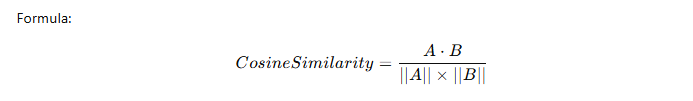

In [10]:
# Python implementation:

v1 = np.array(vector1).reshape(1,-1)
v2 = np.array(vector2).reshape(1,-1)

similarity = cosine_similarity(v1, v2)

print("Cosine Similarity:", similarity[0][0])

Cosine Similarity: 0.5773502691896258


**Interpretation of the Result**

Cosine Similarity Score

0.577

Cosine similarity values range from:

 Value	                             Meaning
 0                                   Completely different documents
 0.3 - 0.5                           Low similarity
 0.5 - 0.7	                         Moderate similarity
0.7 - 1	                             High similarity


Your result:
**0.577**

**Scenario 2: BOW + Jaccard Similarity**

An HR system wants to measure skill overlap between two resumes.

Resume A
*Python, Machine Learning, Data Analysis, SQL*

Resume B
*Python, Deep Learning, Data Mining, SQL*

Now I will:

Convert resumes to sets of unique terms

Compute Jaccard Similarity

Interpret the result

**Step 1: Import Required Library**

In [11]:
import re

**Step 2: Input Resume Text**

In [12]:
resume_a = "Python, Machine Learning, Data Analysis, SQL"
resume_b = "Python, Deep Learning, Data Mining, SQL"

Step 3: Preprocess the Text

Steps:

*Convert to lowercase*

*Split skills using comma*

*Remove extra spaces*

In [13]:
def preprocess(text):
    skills = text.lower().split(",")
    skills = [skill.strip() for skill in skills]
    return set(skills)

**Step 4: Convert Resumes to Sets**

In [14]:
set_a = preprocess(resume_a)
set_b = preprocess(resume_b)

print("Resume A Skills:", set_a)
print("Resume B Skills:", set_b)

Resume A Skills: {'sql', 'python', 'machine learning', 'data analysis'}
Resume B Skills: {'deep learning', 'python', 'sql', 'data mining'}


**Step 5: Compute Jaccard Similarity**

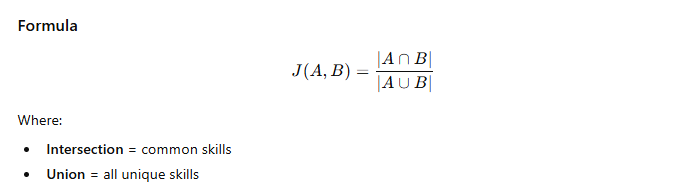

In [15]:
intersection = set_a.intersection(set_b)
union = set_a.union(set_b)

jaccard_similarity = len(intersection) / len(union)

print("Common Skills:", intersection)
print("All Skills:", union)
print("Jaccard Similarity:", jaccard_similarity)

Common Skills: {'sql', 'python'}
All Skills: {'deep learning', 'data analysis', 'data mining', 'sql', 'python', 'machine learning'}
Jaccard Similarity: 0.3333333333333333


Step 7: Interpretation

Jaccard similarity ranges from:

Score	       Meaning
0	No         similarity
0.3	         Low similarity
0.5	         Moderate similarity
1	           Identical sets


The result: 0.33


**Meaning**

Both resumes share two common skills:

Python

SQL

But they differ in other skills like:

Machine Learning vs Deep Learning

Data Analysis vs Data Mining

So the overlap is **moderate** but not **high**.

**Scenario 3: TF-IDF + Cosine Similarity**

A plagiarism detection system compares two assignments.

Document A
*Natural Language Processing enables computers to understand human language.*

Document B
*NLP allows machines to interpret and process human languages.*

Goal:
1. Compute TF-IDF vectors
2. Calculate Cosine Similarity
3. Explain why TF-IDF is better than BOW

**Step 1: Import Required Libraries**

I use scikit-learn, which has built-in TF-IDF and cosine similarity.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [18]:
pip install scikit-learn

**Step 2: Input Documents**



In [19]:
doc1 = "Natural Language Processing enables computers to understand human language."
doc2 = "NLP allows machines to interpret and process human languages."

documents = [doc1, doc2]

**Step 3: Compute TF-IDF Vectors**

*TF-IDF converts documents into numerical vectors based on word importance.*

In [21]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)


Let’s see the features (words):

In [22]:
print(vectorizer.get_feature_names_out())

['allows' 'and' 'computers' 'enables' 'human' 'interpret' 'language'
 'languages' 'machines' 'natural' 'nlp' 'process' 'processing' 'to'
 'understand']


**Step 4: Display TF-IDF Vectors**



In [23]:
print(tfidf_matrix.toarray())

[[0.         0.         0.3160305  0.3160305  0.2248583  0.
  0.632061   0.         0.         0.3160305  0.         0.
  0.3160305  0.2248583  0.3160305 ]
 [0.35327777 0.35327777 0.         0.         0.25136004 0.35327777
  0.         0.35327777 0.35327777 0.         0.35327777 0.35327777
  0.         0.25136004 0.        ]]


**Step 5: Calculate Cosine Similarity**

Cosine similarity measures angle between document vectors.

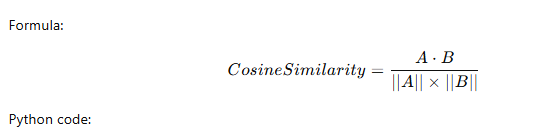

In [24]:
similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])

print("Cosine Similarity:", similarity[0][0])

Cosine Similarity: 0.1130407841661348


Interpretation of Your Result
Similarity Score
0.113

Cosine similarity range:

Value	              Meaning
0	                  Completely different documents
0.1 - 0.3	          Very low similarity
0.3 - 0.5	          Moderate similarity
0.7 - 1	            Highly similar

Your score:

0.113

➡ Very low similarity

**Scenario 4: TF-IDF + Jaccard Similarity**

An e-commerce platform wants to compare two product descriptions to recommend similar products.

Product 1
*Wireless Bluetooth headphones with noise cancellation and long battery life*

Product 2
*Bluetooth wireless earphones featuring active noise cancellation and extended battery performance*

Goal:

*Compute TF-IDF weights*

*Convert them to important term sets*

*Compute Jaccard Similarity*

*Compare Jaccard vs Cosine*

**Step 1: Import Required Libraries**

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

**Step 2: Input Product Descriptions**

In [26]:
doc1 = "Wireless Bluetooth headphones with noise cancellation and long battery life"
doc2 = "Bluetooth wireless earphones featuring active noise cancellation and extended battery performance"

documents = [doc1, doc2]

**Step 3: Compute TF-IDF Weights**

In [27]:
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(documents)

terms = vectorizer.get_feature_names_out()

print("Terms:", terms)
print("\nTF-IDF Matrix:\n", tfidf_matrix.toarray())

Terms: ['active' 'battery' 'bluetooth' 'cancellation' 'earphones' 'extended'
 'featuring' 'headphones' 'life' 'long' 'noise' 'performance' 'wireless']

TF-IDF Matrix:
 [[0.         0.30253071 0.30253071 0.30253071 0.         0.
  0.         0.42519636 0.42519636 0.42519636 0.30253071 0.
  0.30253071]
 [0.36439074 0.25926702 0.25926702 0.25926702 0.36439074 0.36439074
  0.36439074 0.         0.         0.         0.25926702 0.36439074
  0.25926702]]


**Step 4: Convert TF-IDF to Important Term Sets**

*I choose a threshold to select important words.*

In [28]:
threshold = 0.2

doc1_vector = tfidf_matrix.toarray()[0]
doc2_vector = tfidf_matrix.toarray()[1]

important_terms_doc1 = {terms[i] for i, v in enumerate(doc1_vector) if v > threshold}
important_terms_doc2 = {terms[i] for i, v in enumerate(doc2_vector) if v > threshold}

print("Important Terms Doc1:", important_terms_doc1)
print("Important Terms Doc2:", important_terms_doc2)

Important Terms Doc1: {'cancellation', 'long', 'headphones', 'bluetooth', 'life', 'battery', 'noise', 'wireless'}
Important Terms Doc2: {'cancellation', 'featuring', 'performance', 'earphones', 'bluetooth', 'battery', 'extended', 'active', 'noise', 'wireless'}


**Step 5: Compute Jaccard Similarity**

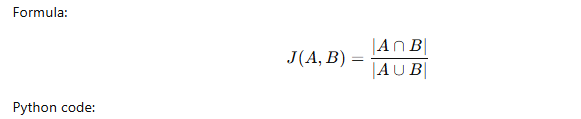

In [29]:
intersection = important_terms_doc1.intersection(important_terms_doc2)
union = important_terms_doc1.union(important_terms_doc2)

jaccard_similarity = len(intersection) / len(union)

print("Common Terms:", intersection)
print("All Important Terms:", union)
print("Jaccard Similarity:", jaccard_similarity)

Common Terms: {'cancellation', 'bluetooth', 'battery', 'noise', 'wireless'}
All Important Terms: {'cancellation', 'featuring', 'long', 'headphones', 'performance', 'earphones', 'bluetooth', 'life', 'battery', 'extended', 'active', 'noise', 'wireless'}
Jaccard Similarity: 0.38461538461538464


**Result Interpretation**

1. Common Important Terms (Intersection)
{'cancellation', 'bluetooth', 'battery', 'noise', 'wireless'}

These are important keywords present in both product descriptions.

Shared product features:

*Bluetooth*

*Wireless*

*Noise cancellation*

*Battery*


These indicate both products are audio devices with similar features.

2. All Important Terms (Union)

Your union contains terms like:

{'cancellation', 'featuring', 'long', 'headphones', 'performance',
 'earphones', 'bluetooth', 'life', 'battery', 'extended', 'active', ...}


These represent all significant words from both descriptions.

Differences between products include:

Product 1	               Product 2
headphones	             earphones
long battery life	       extended battery performance
—	                       featuring / active

These differences increase the union size, lowering similarity.

3. Jaccard Similarity Score: 0.3846

Jaccard similarity range:

Score	         Meaning
0	             No similarity
0.3	           Low similarity
0.5	           Moderate similarity
1	             Identical

Your result:

0.38

➡ Moderate similarity


Why It Is Not Higher

Although the products are similar, different words are used:

**Product 1	**     **Product 2**
headphones	         earphones
long	               extended
life	               performance

Since Jaccard only checks word presence, it treats these as different words.

Final Assignment Conclusion

*TF-IDF was used to identify important terms in both product descriptions. These terms were converted into sets, and Jaccard similarity was computed based on the overlap of important keywords. The resulting similarity score is 0.38, indicating moderate similarity between the two products. Both descriptions share key features such as Bluetooth connectivity, wireless capability, noise cancellation, and battery support, suggesting that they describe similar audio devices. However, differences in wording such as headphones vs earphones and long battery life vs extended battery performance reduce the similarity score.*